# Load and Explore the dataset

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd 
import networkx as nx
import csv
import numpy as np

In [57]:
G = nx.read_edgelist(
    "congress.edgelist",
    create_using=nx.DiGraph(),
    nodetype=int
)

In [58]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("In-degree:", list(G.in_degree())[:10])
print("Out-degree:", list(G.out_degree())[:10])

print(min(G.nodes()), max(G.nodes()))

Nodes: 475
Edges: 13289
In-degree: [(0, 26), (4, 30), (12, 37), (18, 25), (25, 40), (30, 32), (46, 41), (55, 52), (58, 38), (59, 41)]
Out-degree: [(0, 20), (4, 35), (12, 25), (18, 20), (25, 41), (30, 29), (46, 41), (55, 30), (58, 41), (59, 42)]
0 474


In [59]:
# retrieve self loops and isolated nodes
# remove self loops 

self_loops = list(nx.selfloop_edges(G))
print("Self loops:", len(self_loops))

isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")

G.remove_edges_from(self_loops)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Self loops: 0
Isolated nodes: 0
Nodes: 475, Edges: 13289


In [60]:
import json

with open("congress_network_data.json") as f:
    data = json.load(f)

data = data[0]  

username_list = data["usernameList"]

node_to_username = dict(enumerate(username_list))

nx.set_node_attributes(G, node_to_username, "label")

In [61]:
print("Is directed:", nx.is_directed(G))
print("Density:", nx.density(G))
print("Is strongly connected:", nx.is_strongly_connected(G))

Is directed: True
Density: 0.05902287363979569
Is strongly connected: False


In [62]:
# Export in GraphML
nx.write_graphml(G, "congress_network.graphml")

# Degree Analysis

In [42]:
# 2.1 Compute in-degree and out-degree
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Convert to pandas DataFrame for convenience
deg_df = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_degrees[n] for n in G.nodes()],
    "out_degree": [out_degrees[n] for n in G.nodes()]
})
deg_df["total_degree"] = deg_df["in_degree"] + deg_df["out_degree"]

deg_df.sort_values("total_degree", ascending=False).head()

,node,in_degree,out_degree,total_degree
270,322,127,157,284
121,367,51,210,261
88,393,79,111,190
51,254,108,79,187
313,208,121,61,182


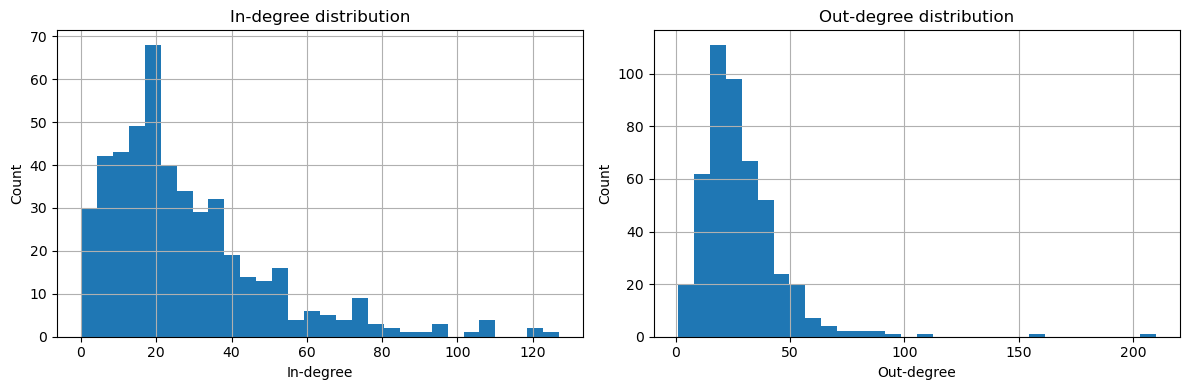

In [43]:
# 2.2 Plot in-degree and out-degree distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_df["in_degree"], bins=30)
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

axes[1].hist(deg_df["out_degree"], bins=30)
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Network Density

In [44]:
density = nx.density(G)
print(f"Network density: {density:.6f}")

Network density: 0.059023


# Reciprocity

In [45]:
# Global reciprocity
global_reciprocity = nx.reciprocity(G)
print(f"Global reciprocity: {global_reciprocity:.4f}")

Global reciprocity: 0.4616


# Connected components

In [46]:
# 5.1 Weakly and strongly connected components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
wcc_sizes = []
for c in wcc:
    wcc_sizes.append(len(c))
wcc_sizes = sorted(wcc_sizes,reverse=True)
#wcc_sizes.sort(reverse=True)

scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)


# 5.2 Analyze size

print(f"Number of weakly connected components: {len(wcc)}")
print(f"    Sizes of the 5 largest WCCs: {wcc_sizes[:5]}")

print(f"Number of strongly connected components: {len(scc)}")
print(f"    Sizes of the 5 largest SCCs: {scc_sizes[:5]}")

Number of weakly connected components: 1
    Sizes of the 5 largest WCCs: [475]
Number of strongly connected components: 7
    Sizes of the 5 largest SCCs: [469, 1, 1, 1, 1]


# Transitivity

In [47]:
# 6.1 Convert to undirected for clustering measures
G_und = G.to_undirected()

# 6.2 Compute global metrics
global_clustering = nx.transitivity(G_und)
avg_local_clustering = nx.average_clustering(G_und)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")
print(f"Average local clustering: {avg_local_clustering:.4f}")

Global clustering coefficient (transitivity): 0.2695
Average local clustering: 0.3014


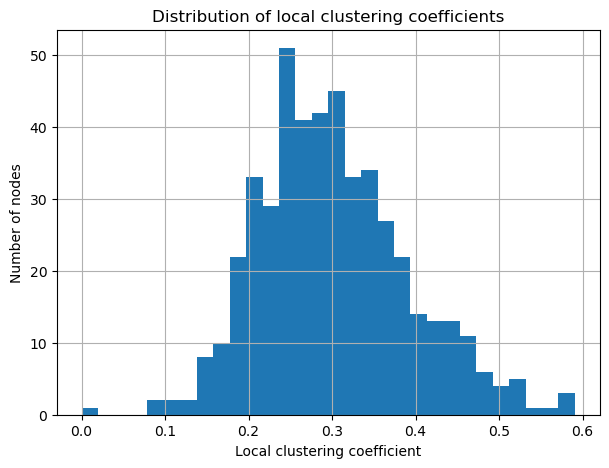

In [48]:
# 6.3 Distribution of local clustering coefficients

clustering_dict = nx.clustering(G_und)
clustering_values = list(clustering_dict.values())

plt.hist(clustering_values, bins=30)
plt.xlabel("Local clustering coefficient")
plt.ylabel("Number of nodes")
plt.title("Distribution of local clustering coefficients")
plt.show()

# Bridges

In [49]:
# 7.1 unidrected graph (already obtained in 6.1)

# 7.2 Compute bridges
bridges = list(nx.bridges(G_und))
print(f"Number of bridges in the undirected graph: {len(bridges)} ({round(len(bridges)/G_und.size()*100,2)}% of edges)")

# Show a few bridges
print("Sample bridges:", bridges[:10])

# 7.3 Compute bridges
local_bridges = list(nx.local_bridges(G_und, with_span = False))
print(f"Number of local bridges in the undirected graph: {len(local_bridges)} - ({round(len(local_bridges)/G_und.size()*100,2)}% of edges)")

# Show a few bridges
print("Sample local bridges:", local_bridges[:10])



Number of bridges in the undirected graph: 0 (0.0% of edges)
Sample bridges: []
Number of local bridges in the undirected graph: 94 - (0.92% of edges)
Sample local bridges: [(18, 217), (58, 381), (76, 336), (341, 419), (17, 152), (79, 396), (79, 407), (213, 240), (250, 69), (250, 406)]


# Assortativity

In [50]:
# 8.1 Degree assortativity
deg_assort = nx.degree_assortativity_coefficient(G_und)
print(f"Degree assortativity coefficient (undirected): {deg_assort:.4f}")

Degree assortativity coefficient (undirected): -0.0785


In [53]:
# Modularity?

# Centrality Measures

In [63]:
# 9.1 Degree centrality (on directed, but we can use total degree via undirected)
deg_cent = nx.degree_centrality(G_und)

# 9.2 Betweenness centrality (can be expensive; we run on undirected)
bet_cent = nx.betweenness_centrality(G_und, normalized=True)

# 9.3 Closeness centrality (undirected for reachability)
clo_cent = nx.closeness_centrality(G_und)

# 9.4 PageRank (directed, based on random walks)
pr = nx.pagerank(G, alpha=0.85)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "betweenness_centrality": [bet_cent[n] for n in G.nodes()],
    "closeness_centrality": [clo_cent[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
})

centrality_df.sort_values("degree_centrality", ascending=False).reset_index(drop=True).head(10)

,node,degree_centrality,betweenness_centrality,closeness_centrality,pagerank
0,367,0.451477,0.068626,0.645777,0.002327
1,322,0.381857,0.037183,0.617188,0.016696
2,254,0.299578,0.022623,0.585185,0.006815
3,208,0.282700,0.015459,0.570397,0.008885
4,393,0.272152,0.013559,0.570397,0.005330
5,190,0.267932,0.013048,0.557647,0.006653
6,111,0.253165,0.012495,0.571084,0.007745
7,192,0.238397,0.009900,0.553738,0.007491
8,269,0.236287,0.007737,0.555035,0.010660
9,385,0.234177,0.007450,0.526667,0.006438


In [65]:
# 9.5 Show top nodes by different centralities

def show_top(df, col, k=10):
    print(f"\nTop {k} nodes by {col}:")
    display(
        df.sort_values(col, ascending=False)
          .reset_index(drop=True)
          .head(k)[["node", col]]
    )

labels = nx.get_node_attributes(G, "label")
centrality_df["label"] = centrality_df["node"].map(labels)

show_top(centrality_df, "degree_centrality")
show_top(centrality_df, "betweenness_centrality")
show_top(centrality_df, "closeness_centrality")
show_top(centrality_df, "pagerank")


Top 10 nodes by degree_centrality:


,node,degree_centrality
0,367,0.451477
1,322,0.381857
2,254,0.299578
3,208,0.282700
4,393,0.272152
5,190,0.267932
6,111,0.253165
7,192,0.238397
8,269,0.236287
9,385,0.234177



Top 10 nodes by betweenness_centrality:


,node,betweenness_centrality
0,367,0.068626
1,322,0.037183
2,254,0.022623
3,208,0.015459
4,17,0.014895
5,71,0.013771
6,393,0.013559
7,461,0.013285
8,92,0.013185
9,190,0.013048



Top 10 nodes by closeness_centrality:


,node,closeness_centrality
0,367,0.645777
1,322,0.617188
2,254,0.585185
3,111,0.571084
4,393,0.570397
5,208,0.570397
6,461,0.561611
7,92,0.558304
8,190,0.557647
9,71,0.556338



Top 10 nodes by pagerank:


,node,pagerank
0,322,0.016696
1,147,0.012845
2,389,0.011028
3,269,0.010660
4,215,0.010580
5,208,0.008885
6,92,0.008246
7,246,0.008157
8,303,0.008033
9,113,0.008026


# Community Detection and Comparison with Ground Truth

In [33]:
# For community detection and evaluation
try:
    from networkx.algorithms.community import louvain_communities
    HAVE_NX_LOUVAIN = True
except ImportError:
    HAVE_NX_LOUVAIN = False

try:
    import community as community_louvain
    HAVE_COMMUNITY_LOUVAIN = True
except ImportError:
    HAVE_COMMUNITY_LOUVAIN = False

try:
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
    HAVE_SKLEARN = True
except ImportError:
    HAVE_SKLEARN = False

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

In [34]:
# 10.1 Run community detection (Louvain)

if HAVE_NX_LOUVAIN:
    print("Using NetworkX's louvain_communities...")
    louvain_comms = louvain_communities(G_und, seed=42)
elif HAVE_COMMUNITY_LOUVAIN:
    print("Using python-louvain (community_louvain)...")
    partition = community_louvain.best_partition(G_und, random_state=42)
    # Convert partition dict {node: community_id} to list of sets
    comm_dict = {}
    for node, cid in partition.items():
        comm_dict.setdefault(cid, set()).add(node)
    louvain_comms = list(comm_dict.values())
else:
    print("No Louvain implementation found. Please install 'python-louvain' or upgrade NetworkX.")
    louvain_comms = []

print(f"Detected {len(louvain_comms)} communities.")

Using NetworkX's louvain_communities...
Detected 4 communities.


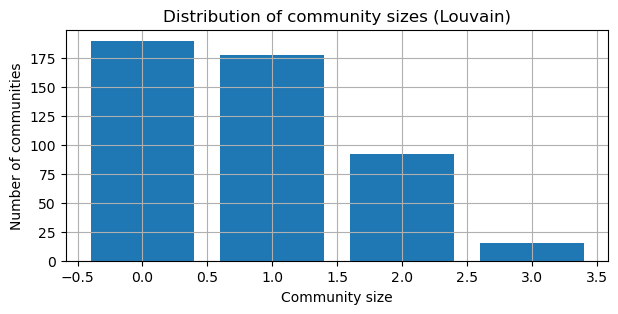

Number of communities: 4
Smallest community: 15 nodes
Largest community: 190 nodes


In [35]:
# Compute community sizes
community_sizes = sorted([len(c) for c in louvain_comms], reverse = True)

# Plot histogram
plt.figure(figsize=(7,3))
plt.bar(range(len(community_sizes)),community_sizes)
plt.xlabel("Community size")
plt.ylabel("Number of communities")
plt.title("Distribution of community sizes (Louvain)")
plt.grid(True)
plt.show()

# Print summary stats
print(f"Number of communities: {len(community_sizes)}")
print(f"Smallest community: {min(community_sizes)} nodes")
print(f"Largest community: {max(community_sizes)} nodes")